### Build a basic chatbot with Langgraph (GRAPH API)

In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

State creation

In [2]:
# Messages have the type "list". The "add_messages" function in the annotation defines
# how this state key should be updated. In this case, it appends messages to the list,
# rather than overwriting them

class State(TypedDict):
    messages: Annotated[list, add_messages]


Model

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model = "llama-3.3-70b-versatile")

In [5]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.9', 'langchain': '1.3.12'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000020C13D19A90>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000020C13D1A510>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [6]:
llm = init_chat_model("groq:llama-3.3-70b-versatile")

In [7]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.9', 'langchain': '1.3.12'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000020C13D82850>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000020C13D83250>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

Creating node functionality

In [8]:
def chatbot(state:State):
    return {"messages": [llm.invoke(state["messages"])]}

Building a graph

In [9]:
graph_builder = StateGraph(State)

# Adding node
graph_builder.add_node("llmchatbot", chatbot)

# Adding edges
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

# Compile the graph
graph = graph_builder.compile()

Visualize the graph

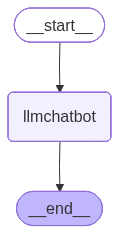

In [10]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [11]:
response = graph.invoke({
    "messages": "Hi"
})

In [12]:
response["messages"]

[HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='a7f9b718-fb91-4da2-b7b0-0ee63c08bfa0'),
 AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 'total_tokens': 59, 'completion_time': 0.061138176, 'completion_tokens_details': None, 'prompt_time': 0.001934683, 'prompt_tokens_details': None, 'queue_time': 0.161318115, 'total_time': 0.063072859}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f4d36-06e6-7f12-aa37-dfd3afa5bb9f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59})]

In [13]:
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [14]:
for event in graph.stream({"messages": "Hi How are you?"}):
    print(event)

{'llmchatbot': {'messages': [AIMessage(content="Hello. I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to assist you. How can I help you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 40, 'prompt_tokens': 40, 'total_tokens': 80, 'completion_time': 0.090565953, 'completion_tokens_details': None, 'prompt_time': 0.001983644, 'prompt_tokens_details': None, 'queue_time': 0.053342245, 'total_time': 0.092549597}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f4d36-0e20-7641-8d93-9c121acf8c22-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 40, 'output_tokens': 40, 'total_tokens': 80})]}}


In [15]:
for event in graph.stream({"messages": "Hi How are you?"}):
    for value in event.values():
        print(value)

{'messages': [AIMessage(content="I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help you with any questions or tasks you might have. How can I assist you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 46, 'prompt_tokens': 40, 'total_tokens': 86, 'completion_time': 0.107618944, 'completion_tokens_details': None, 'prompt_time': 0.000992112, 'prompt_tokens_details': None, 'queue_time': 0.054655038, 'total_time': 0.108611056}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f4d36-0f28-7f61-9b90-a8114fb3ef17-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 40, 'output_tokens': 46, 'total_tokens': 86})]}


In [16]:
for event in graph.stream({"messages": "Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm doing well, thanks for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to chat with you. How about you? How's your day going so far?


### Chatbot with tool

In [17]:
load_dotenv()

True

In [18]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results = 2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the n

In [19]:
# Custom function

def multiply(a:int, b:int) -> int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [20]:
tools = [tool, multiply]

In [21]:
llm_with_tool = llm.bind_tools(tools)

In [22]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.9', 'langchain': '1.3.12'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000020C13D82850>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000020C13D83250>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search 

In [23]:
# StateGraph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Node definition
def tool_calling_llm(state:State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}


# Nodes
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools", END)

# Compile the graph
graph = builder.compile()

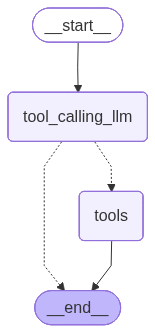

In [24]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [25]:
response = graph.invoke({"messages": "What is the recent AI news"})

In [26]:
response["messages"][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.businessinsider.com/new-ai-model-announcements-openai-meta-grok-2026-7", "title": "The Whirlwind 72 Hours of Rival AI Announcements - Business Insider", "score": 0.79958355, "published_date": "Fri, 10 Jul 2026 15:24:46 GMT", "content": "If we\'re having trouble keeping up with all the AI news this week, we can\'t imagine how you feel. The last three days have been a nonstop parade of new products, features, and frontier model releases from the leading AI labs. There are new names like \\"Sol\\" and \\"Terra,\\" as well as new features for image creation and voice assistants. Behind the scenes, Perplexity is quietly working on a new coding tool called \\"Teammate\\" to compete with Anthropic and OpenAI, Business Insider exclusively reported on. We know the AI labs like to one-up each other, but this week underscored that you shouldn\'t expect a summer slowdown in the 

In [27]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the recent AI news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (a2h4mzb7b)
 Call ID: a2h4mzb7b
  Args:
    query: recent AI news
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.businessinsider.com/new-ai-model-announcements-openai-meta-grok-2026-7", "title": "The Whirlwind 72 Hours of Rival AI Announcements - Business Insider", "score": 0.79958355, "published_date": "Fri, 10 Jul 2026 15:24:46 GMT", "content": "If we're having trouble keeping up with all the AI news this week, we can't imagine how you feel. The last three days have been a nonstop parade of new products, features, and frontier model releases from the leading AI l

In [28]:
response = graph.invoke({"messages": "What is 2 multiplied by 3"})

In [29]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiplied by 3
================================== Ai Message ==================================
Tool Calls:
  multiply (10mjg41nm)
 Call ID: 10mjg41nm
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [31]:
response = graph.invoke({"messages": "What is 5 multiplied by 2 and then multiply 10"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2 and then multiply 10
================================== Ai Message ==================================
Tool Calls:
  multiply (z31zk2mbf)
 Call ID: z31zk2mbf
  Args:
    a: 5
    b: 2
  multiply (gnmw4gs69)
 Call ID: gnmw4gs69
  Args:
    a: 10
    b: 10
================================= Tool Message =================================
Name: multiply

10
================================= Tool Message =================================
Name: multiply

100


In [32]:
response = graph.invoke({"messages": "Give me the recent AI news and then multiply 5 by 10"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Give me the recent AI news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (2y2hkwm2a)
 Call ID: 2y2hkwm2a
  Args:
    query: recent AI news
    search_depth: basic
    topic: news
  multiply (6ev79syp3)
 Call ID: 6ev79syp3
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.businessinsider.com/new-ai-model-announcements-openai-meta-grok-2026-7", "title": "The Whirlwind 72 Hours of Rival AI Announcements - Business Insider", "score": 0.79958355, "published_date": "Fri, 10 Jul 2026 15:24:46 GMT", "content": "If we're having trouble keeping up with all the AI news this week, we can't imagine how you feel. The last three days hav

### ReAct Agent Architecture

In [33]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

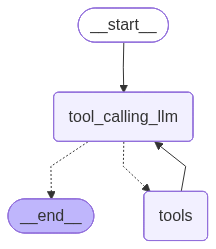

In [34]:
from langgraph.graph import START, END, StateGraph
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# tool definition
def tool_calling_llm(state:State):
    return{"messages": [llm_with_tool.invoke(state["messages"])]}

# Nodes
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm")

# Compile the graph
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [35]:
response = graph.invoke({"messages": "Give me the recent AI news and then multiply 5 by 10"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Give me the recent AI news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (naks3q6n9)
 Call ID: naks3q6n9
  Args:
    query: recent AI news
    time_range: day
    topic: news
  multiply (gbsfwwrpw)
 Call ID: gbsfwwrpw
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.businessinsider.com/new-ai-model-announcements-openai-meta-grok-2026-7", "title": "The Whirlwind 72 Hours of Rival AI Announcements - Business Insider", "score": 0.79958355, "published_date": "Fri, 10 Jul 2026 15:24:46 GMT", "content": "If we're having trouble keeping up with all the AI news this week, we can't imagine how you feel. The last three days have be

### Adding Memory in Agentic Graph

In [36]:
response = graph.invoke({"messages": "Hello! My name is Nijitha"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hello! My name is Nijitha
================================== Ai Message ==================================

Hello Nijitha! It's nice to meet you. Is there something I can help you with or would you like to chat?


In [37]:
response = graph.invoke({"messages": "What is my name"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is my name
================================== Ai Message ==================================

I don't have information about your name. This conversation just started, and I don't have any prior knowledge about you. If you'd like to share your name, I'd be happy to chat with you!


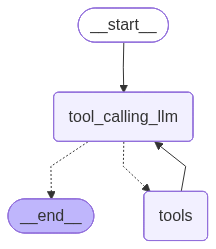

In [45]:
from langgraph.graph import START, END, StateGraph
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

def tool_calling_llm(state:State):
    return {"messages": [llm.invoke(state["messages"])]}

builder = StateGraph(State)

builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm")

graph = builder.compile(checkpointer = memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [46]:
config = {"configurable": {"thread_id": "1"}}

In [47]:
response = graph.invoke({"messages":"Hi My name is Nijitha"}, config=config)
response

{'messages': [HumanMessage(content='Hi My name is Nijitha', additional_kwargs={}, response_metadata={}, id='88ccd0a7-67a6-4257-94b5-ffc5588e7ea1'),
  AIMessage(content="Hello Nijitha, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 43, 'total_tokens': 72, 'completion_time': 0.049318501, 'completion_tokens_details': None, 'prompt_time': 0.002441516, 'prompt_tokens_details': None, 'queue_time': 0.33025015, 'total_time': 0.051760017}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f4d4d-ca4c-77c1-864c-21dc333283ce-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 43, 'output_tokens': 29, 'total_tokens': 72})]}

In [48]:
response["messages"][-1].content

"Hello Nijitha, it's nice to meet you. Is there something I can help you with or would you like to chat?"

In [49]:
response = graph.invoke({"messages":"What is my name"}, config=config)
response["messages"][-1].content

'Your name is Nijitha.'

In [50]:
response = graph.invoke({"messages":"Do you remember my name"}, config=config)
response["messages"][-1].content

'Yes, I remember your name. You told me earlier that your name is Nijitha.'

### Streaming

In [51]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [52]:
def superbot(state:State):
    return{"messages": [llm.invoke(state["messages"])]}

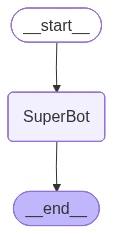

In [54]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

builder = StateGraph(State)

builder.add_node("SuperBot", superbot)

builder.add_edge(START, "SuperBot")
builder.add_edge("SuperBot", END)

graph = builder.compile(checkpointer = memory)

display(Image(graph.get_graph().draw_mermaid_png()))


In [55]:
config = {"configurable": {"thread_id": "1"}}
graph.invoke({"messages": "Hi, My name is Nijitha and I like cricket"}, config = config)

{'messages': [HumanMessage(content='Hi, My name is Nijitha and I like cricket', additional_kwargs={}, response_metadata={}, id='ed2baa87-2dca-4397-b8ea-8a38fbdb9053'),
  AIMessage(content="Nice to meet you, Nijitha! Cricket is an exciting sport, isn't it? Which team or player is your favorite? Are you a fan of international cricket, IPL, or any other format? Let's chat about cricket!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 48, 'total_tokens': 98, 'completion_time': 0.164042243, 'completion_tokens_details': None, 'prompt_time': 0.002675522, 'prompt_tokens_details': None, 'queue_time': 0.368734504, 'total_time': 0.166717765}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_f8b414701e', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f4d60-1c63-76d1-996c-b2c83250923a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 48, '

### Streaming

Methods: .stream() and astream()
* These methods are sync and async methods for streaming back results.

Additional parameters in streaming methods for graph state
* Values: This streams the full set of the graph and each node is called
* updates: This streams updates to the state of the graph after each node is called

In [56]:
# Stream mode - update

config = {"configurable": {"thread_id": "3"}}

for chunk in graph.stream({"messages": "Hi, My name is Nijitha and I like cricket"}, config = config, stream_mode = "updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Nice to meet you, Nijitha! Cricket is an exciting sport, and there are so many thrilling matches and talented players to follow. Are you a fan of a particular team or player? Do you have a favorite format of the game, such as Test matches, One-Day Internationals (ODIs), or Twenty20 (T20) cricket?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 74, 'prompt_tokens': 48, 'total_tokens': 122, 'completion_time': 0.25418786, 'completion_tokens_details': None, 'prompt_time': 0.002109413, 'prompt_tokens_details': None, 'queue_time': 0.056741787, 'total_time': 0.256297273}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f4d73-9c11-77c3-8c73-0c1ff6c36edd-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 48, 'output_tokens': 74, 'total_tokens': 122})]}

In [57]:
for chunk in graph.stream({"messages": "Hi, My name is Nijitha and I like cricket"}, config = config, stream_mode = "values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, My name is Nijitha and I like cricket', additional_kwargs={}, response_metadata={}, id='6f8f93dc-b2e1-4080-97d8-76c92bd75f1d'), AIMessage(content='Nice to meet you, Nijitha! Cricket is an exciting sport, and there are so many thrilling matches and talented players to follow. Are you a fan of a particular team or player? Do you have a favorite format of the game, such as Test matches, One-Day Internationals (ODIs), or Twenty20 (T20) cricket?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 74, 'prompt_tokens': 48, 'total_tokens': 122, 'completion_time': 0.25418786, 'completion_tokens_details': None, 'prompt_time': 0.002109413, 'prompt_tokens_details': None, 'queue_time': 0.056741787, 'total_time': 0.256297273}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f4d73-9c11-77c3

In [58]:
config = {"configurable": {"thread_id": "4"}}

for chunk in graph.stream({"messages": "Hi, My name is Nijitha and I like cricket"}, config = config, stream_mode = "updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Hello Nijitha! It's nice to meet you. Cricket is a fantastic sport, and I'm sure you must be excited about the thrill and strategy involved in the game. Which team or player is your favorite? Are you a fan of any particular format, like Test matches, ODIs, or T20s?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 67, 'prompt_tokens': 48, 'total_tokens': 115, 'completion_time': 0.262069837, 'completion_tokens_details': None, 'prompt_time': 0.002193021, 'prompt_tokens_details': None, 'queue_time': 0.161183357, 'total_time': 0.264262858}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f4d75-b50e-7302-8844-bb479397755a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 48, 'output_tokens': 67, 'total_tokens': 115})]}}


In [59]:
for chunk in graph.stream({"messages": "I also like football"}, config = config, stream_mode = "values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, My name is Nijitha and I like cricket', additional_kwargs={}, response_metadata={}, id='7f1111fa-a3ea-4bf0-983e-af6660433e31'), AIMessage(content="Hello Nijitha! It's nice to meet you. Cricket is a fantastic sport, and I'm sure you must be excited about the thrill and strategy involved in the game. Which team or player is your favorite? Are you a fan of any particular format, like Test matches, ODIs, or T20s?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 67, 'prompt_tokens': 48, 'total_tokens': 115, 'completion_time': 0.262069837, 'completion_tokens_details': None, 'prompt_time': 0.002193021, 'prompt_tokens_details': None, 'queue_time': 0.161183357, 'total_time': 0.264262858}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f4d75-b50e-7302-8844-bb479397755a-0', tool_cal

In [61]:
config = {"configurable": {"thread_id": "5"}}

async for event in graph.astream_events({"messages": ["Hi, My name is Nijitha and I like cricket"]}, config, version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi, My name is Nijitha and I like cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019f4d79-c1c9-7683-83f4-43597786a0aa', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi, My name is Nijitha and I like cricket', additional_kwargs={}, response_metadata={}, id='a7cbd7f6-f819-492c-bc56-38a0e5d4bfb8')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '019f4d79-c1f2-73a1-a085-8def3364cdf3', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:0071aac6-dd47-65ce-10e1-0d84ac9d4d9e'}, 'parent_ids': ['019f4d79-c1c9-7683-83f4-43597786a0aa']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMe